In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time 
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,recall_score,precision_score,confusion_matrix,f1_score,ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier, plot_tree
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE,BorderlineSMOTE,ADASYN
from sklearn.model_selection import GridSearchCV

In [3]:
# upload file kaggle.json
from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"naubass","key":"971f5810f2bafc6d58b33c053aefdf0e"}'}

In [4]:
# download dataset from kaggle
!kaggle datasets download -d algozee/teenager-menthal-healy/
!unzip -qq teenager-menthal-healy.zip

Dataset URL: https://www.kaggle.com/datasets/algozee/teenager-menthal-healy/versions/
License(s): apache-2.0
100% 15.8k/15.8k [00:00<00:00, 34.1MB/s]



In [5]:
df = pd.read_csv('Teen_Mental_Health_Dataset.csv')

In [6]:
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


In [8]:
# check null data
df.isnull().sum()

,0
age,0
gender,0
daily_social_media_hours,0
platform_usage,0
sleep_hours,0
screen_time_before_sleep,0
academic_performance,0
physical_activity,0
social_interaction_level,0
stress_level,0


In [9]:
# check duplicate data
df.duplicated().sum()

np.int64(0)

[Text(0, 0, ''), Text(1, 0, ''), Text(2, 0, '')]

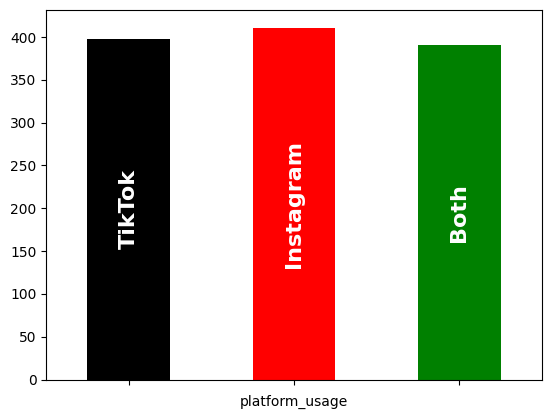

In [10]:
# plot bar platform usage
labels = ['TikTok', 'Instagram', 'Both']
ax = df['platform_usage'].value_counts().reindex(labels).plot.bar(color=['black', 'red', 'green'])
ax.bar_label(ax.containers[0], labels=labels, label_type='center', color='white', rotation=90,fontsize=16, fontweight='bold')
ax.set_xticklabels([])

depression_label
0    1169
1      31
Name: count, dtype: int64


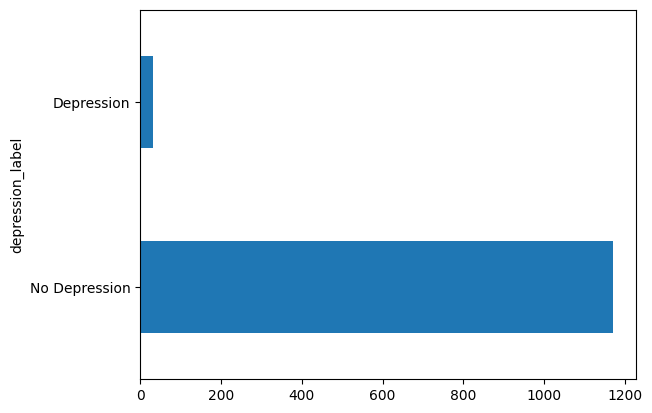

In [11]:
depression_label = 'depression_label'
df['depression_label'].value_counts().rename(index={1: 'Depression', 0: 'No Depression'}).plot.barh()
print(df['depression_label'].value_counts())

In [12]:
print(df['social_interaction_level'].unique())
print(df['platform_usage'].unique())

['low' 'high' 'medium']
['Instagram' 'TikTok' 'Both']


In [13]:
# mapping dataframe
df['gender'] = df['gender'].map({'male':1,'female':0})
df['social_interaction_level'] = df['social_interaction_level'].map({'low':0, 'high':1, 'medium':2})
df['platform_usage'] = df['platform_usage'].map({'Instagram':0 ,'TikTok':1, 'Both':2})

print(df.isnull().sum().max() , ', if 0 there is no null')

0 , if 0 there is no null


<Axes: >

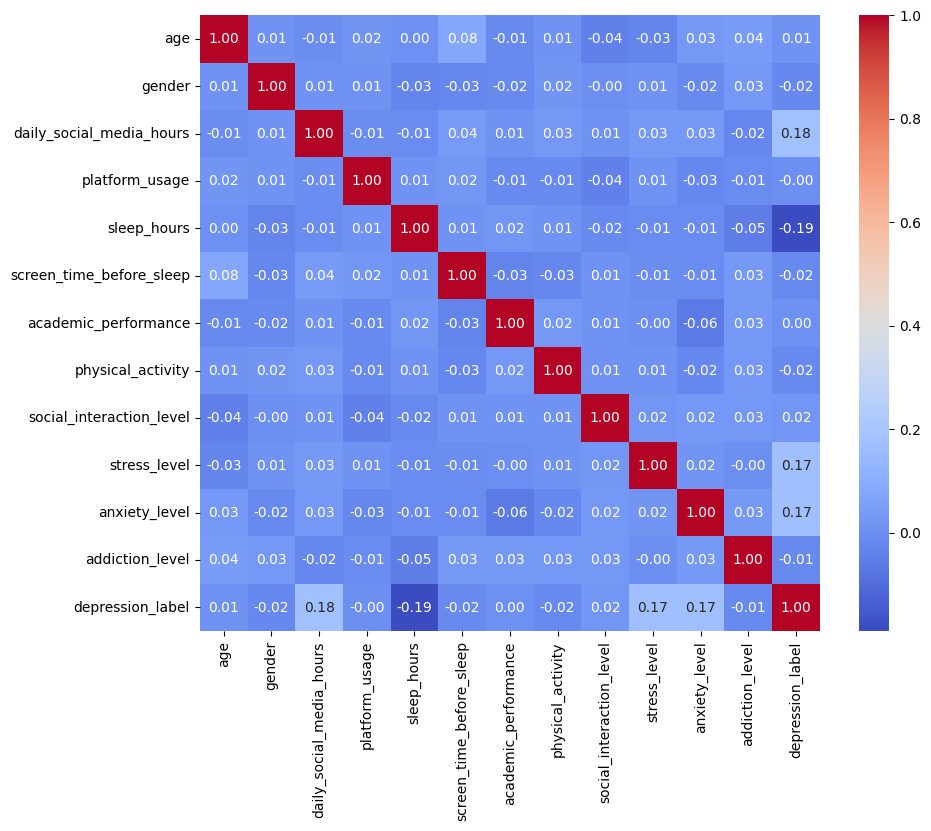

In [14]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")

In [15]:
Feature = df.drop([depression_label], axis=1)
Label = df[depression_label]
print('The DataSize: ', len(Label))

The DataSize:  1200


# Split Dataset & SMOTE Balancing

In [16]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(Feature, Label, test_size=0.2, random_state=42, stratify=Label)

print('Training Size: ', len(y_train))
print('Testing Size: ', len(y_test))
print('\nTest labels counts:')
print(y_test.value_counts())

Training Size:  960
Testing Size:  240

Test labels counts:
depression_label
0    234
1      6
Name: count, dtype: int64


In [17]:
# balancing dataset with SMOTE
smote = SMOTETomek(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Before Balancing
print('Training Size Before Balancing: ', len(y_train))

# After Balancing
print('Training Size After Balancing with SMOTE: ', len(y_train_resampled))

Training Size Before Balancing:  960
Training Size After Balancing with SMOTE:  1870


# Desicion Tree Training

 Time := 0.03  seconds
Accuracy Score on Training Data:  0.9946524064171123
Accuracy Score on Testing Data:  0.9916666666666667
Recall Score on Testing Data:  0.6666666666666666
Precision Score on Testing Data:  1.0
F1 Score on Testing Data:  0.8


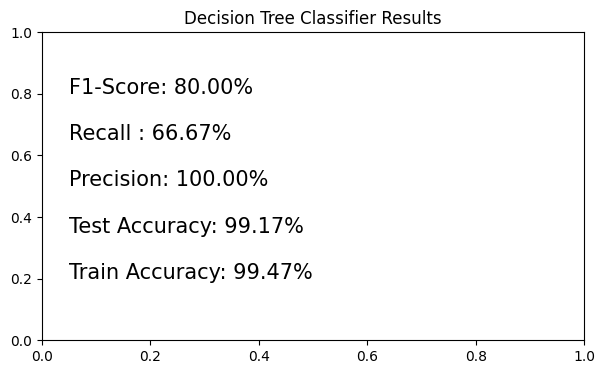

In [18]:
starttime=time.perf_counter()

# Training with Decision Tree
model_dt = DecisionTreeClassifier(max_depth=4, random_state=42, min_samples_split=50, min_samples_leaf=35)
model_dt.fit(X_train_resampled, y_train_resampled)

# Predictions with Decision Tree
train_prediction_dt = model_dt.predict(X_train_resampled)
test_prediction_dt = model_dt.predict(X_test)

# Accuracy Score
train_accuracy_dt = accuracy_score(y_train_resampled, train_prediction_dt)
test_accuracy_dt = accuracy_score(y_test, test_prediction_dt)

# Evaluation Score
recall_score_dt = recall_score(y_test, test_prediction_dt)
precision_score_dt = precision_score(y_test, test_prediction_dt)
f1_score_dt = f1_score(y_test, test_prediction_dt)
cm_dt = confusion_matrix(y_test, test_prediction_dt)

print(' Time :=',format(time.perf_counter()-starttime,'.2f'),' seconds')
print('Accuracy Score on Training Data: ', train_accuracy_dt)
print('Accuracy Score on Testing Data: ', test_accuracy_dt)
print('Recall Score on Testing Data: ', recall_score_dt)
print('Precision Score on Testing Data: ', precision_score_dt)
print('F1 Score on Testing Data: ', f1_score_dt)

# Plot visualize
plt.figure(figsize=(7, 4))
plt.title('Decision Tree Classifier Results')
plt.text(0.05, 0.65, f"Recall : {recall_score_dt * 100:.2f}%", fontsize=15, ha='left')
plt.text(0.05, 0.50, f"Precision: {precision_score_dt * 100:.2f}%", fontsize=15, ha='left')
plt.text(0.05, 0.80, f"F1-Score: {f1_score_dt * 100:.2f}%", fontsize=15, ha='left')
plt.text(0.05, 0.20, f"Train Accuracy: {train_accuracy_dt * 100:.2f}%", fontsize=15, ha='left')
plt.text(0.05, 0.35, f"Test Accuracy: {test_accuracy_dt * 100:.2f}%", fontsize=15, ha='left')
plt.show()

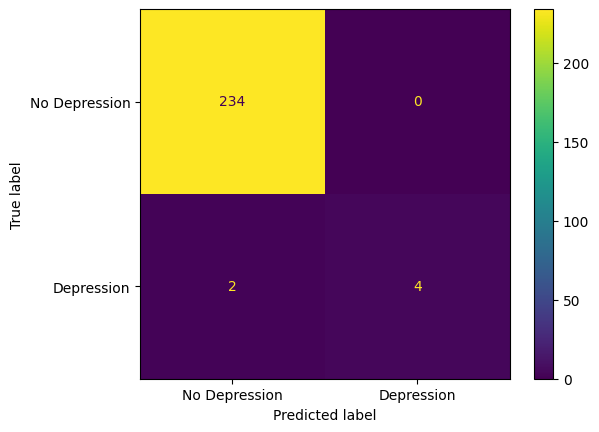

In [19]:
# Confusion Matrix Display
ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=['No Depression', 'Depression']
).plot()

plt.show()

/tmp/ipykernel_3330/2156020243.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=metrics_names, y=[v * 100 for v in metrics_values], palette='viridis')


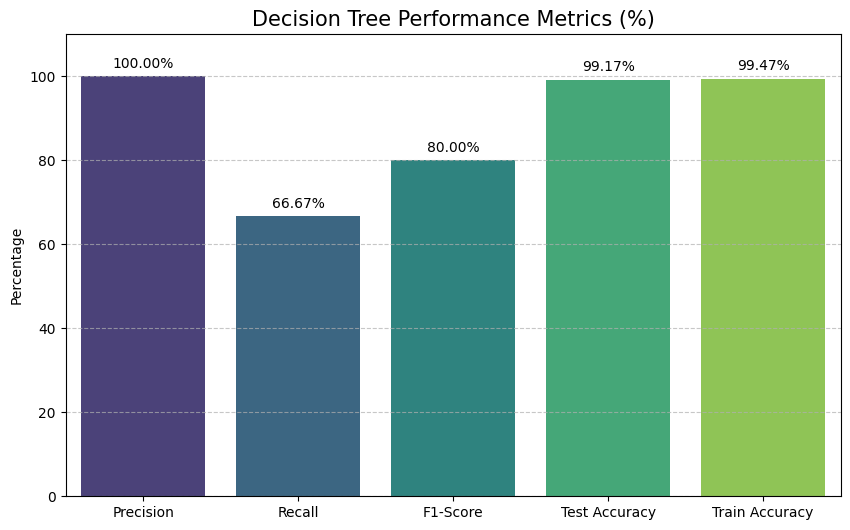

In [20]:
# Plot Grafik Accuracy
import seaborn as sns

# Data untuk plotting
metrics_names = ['Precision', 'Recall', 'F1-Score', 'Test Accuracy', 'Train Accuracy']
metrics_values = [precision_score_dt, recall_score_dt, f1_score_dt, test_accuracy_dt, train_accuracy_dt]

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=metrics_names, y=[v * 100 for v in metrics_values], palette='viridis')

# Menambahkan label angka di atas bar
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f') + '%',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points')

plt.ylim(0, 110)
plt.title('Decision Tree Performance Metrics (%)', fontsize=15)
plt.ylabel('Percentage')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

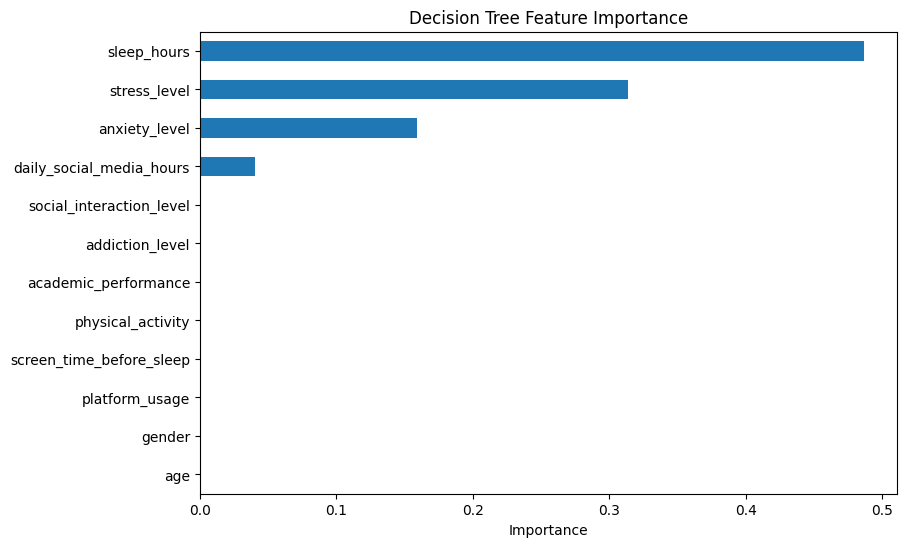

In [21]:
pd.Series(model_dt.feature_importances_, index=X_train.columns).sort_values().plot.barh(
    figsize=(9,6), title='Decision Tree Feature Importance', xlabel='Importance'
)
plt.show()

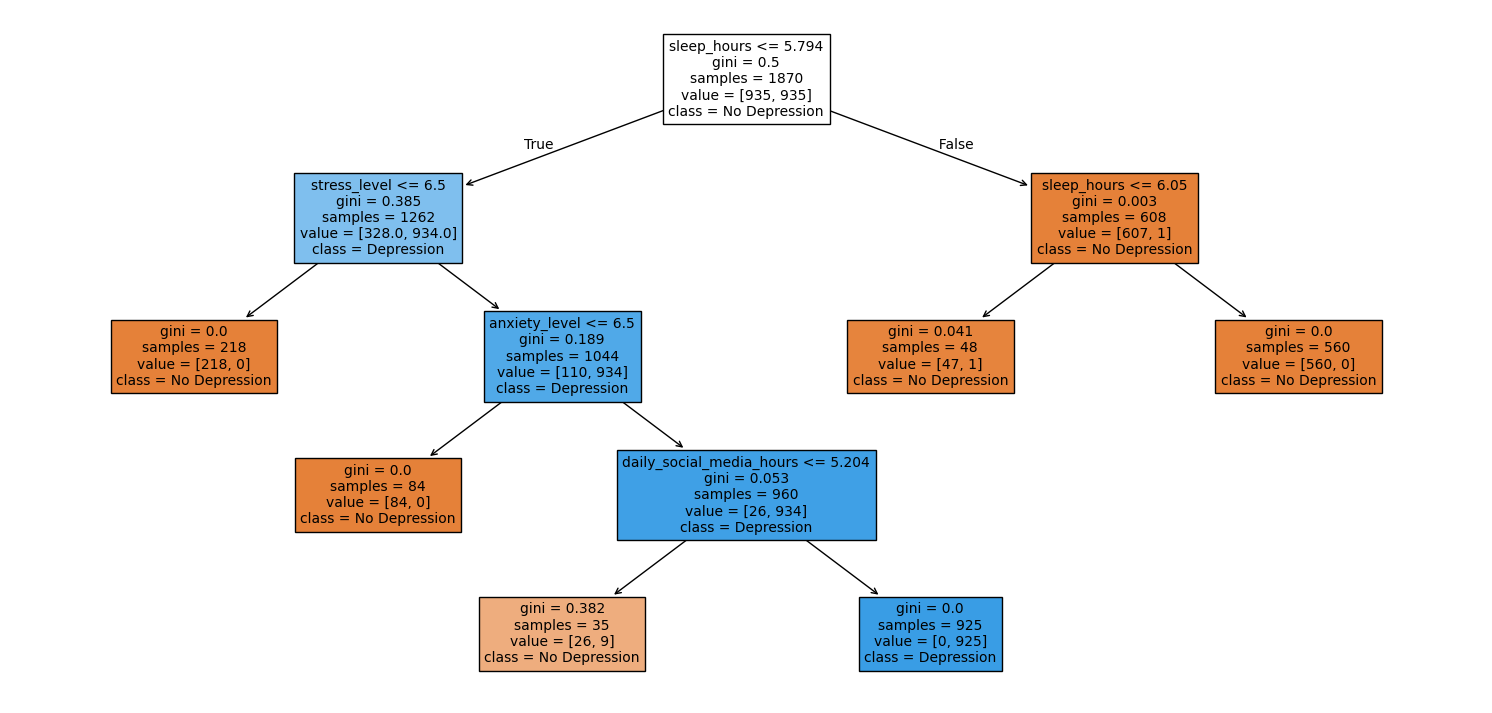

In [22]:
plt.figure(figsize=(19, 9))
plot_tree(model_dt,
          max_depth=5,
          feature_names=X_train.columns,
          class_names=["No Depression", "Depression"],
          filled=True,
          rounded=False,
          fontsize=10)
plt.show()

# XGboost Training

 Time := 0.27  seconds
Accuracy Score on Training Data:  1.0
Accuracy Score on Testing Data:  1.0
Recall Score on Testing Data:  1.0
Precision Score on Testing Data:  1.0
F1 Score on Testing Data:  1.0


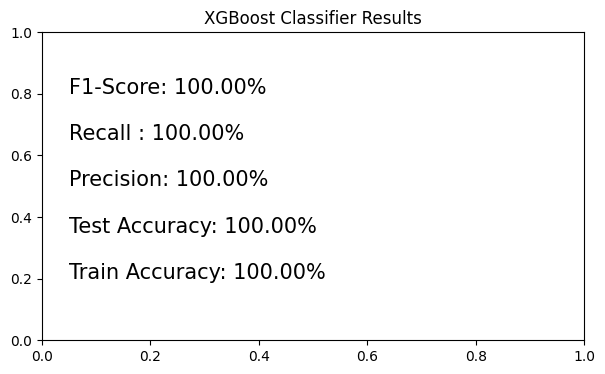

In [23]:
starttime=time.perf_counter()

Best_Grid_Params= {'n_estimators': 500, 'learning_rate': 0.01, 'max_depth': 10,'gamma':0.1}

model_xg = XGBClassifier(
    **Best_Grid_Params,
    n_jobs = -1,
    random_state=42,
)

model_xg.fit(X_train, y_train)

# Predictions with XGBoost
train_prediction_xg = model_xg.predict(X_train)
test_prediction_xg = model_xg.predict(X_test)

# Training Accuracy with XGBoost
train_accuracy_xg = accuracy_score(y_train, train_prediction_xg)
test_accuracy_xg = accuracy_score(y_test, test_prediction_xg)

# Evaluation Model
recall_score_xg = recall_score(y_test, test_prediction_xg)
precision_score_xg = precision_score(y_test, test_prediction_xg)
f1_score_xg = f1_score(y_test, test_prediction_xg)
cm_xg = confusion_matrix(y_test, test_prediction_xg)

print(' Time :=',format(time.perf_counter()-starttime,'.2f'),' seconds')
print('Accuracy Score on Training Data: ', train_accuracy_xg)
print('Accuracy Score on Testing Data: ', test_accuracy_xg)
print('Recall Score on Testing Data: ', recall_score_xg)
print('Precision Score on Testing Data: ', precision_score_xg)
print('F1 Score on Testing Data: ', f1_score_xg)

# Plot Visualization
plt.figure(figsize=(7, 4))
plt.title('XGBoost Classifier Results')
plt.text(0.05, 0.65, f"Recall : {recall_score_xg * 100:.2f}%", fontsize=15, ha='left')
plt.text(0.05, 0.50, f"Precision: {precision_score_xg * 100:.2f}%", fontsize=15, ha='left')
plt.text(0.05, 0.80, f"F1-Score: {f1_score_xg * 100:.2f}%", fontsize=15, ha='left')
plt.text(0.05, 0.20, f"Train Accuracy: {train_accuracy_xg * 100:.2f}%", fontsize=15, ha='left')
plt.text(0.05, 0.35, f"Test Accuracy: {test_accuracy_xg * 100:.2f}%", fontsize=15, ha='left')
plt.show()

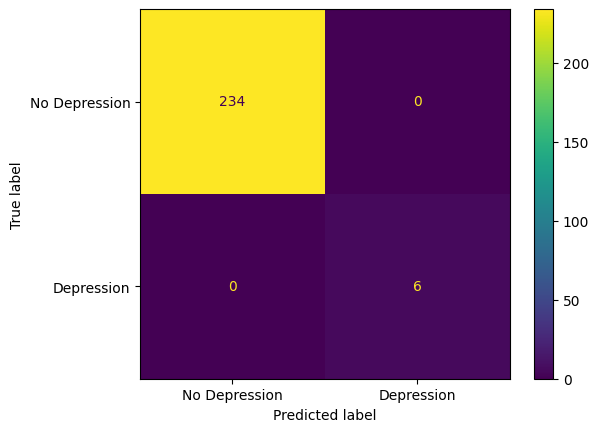

In [24]:
# Confusion Matrix Display
ConfusionMatrixDisplay(
    confusion_matrix=cm_xg,
    display_labels=['No Depression', 'Depression']
).plot()

plt.show()

/tmp/ipykernel_3330/3222556841.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=metrics_names, y=[v * 100 for v in metrics_values], palette='viridis')


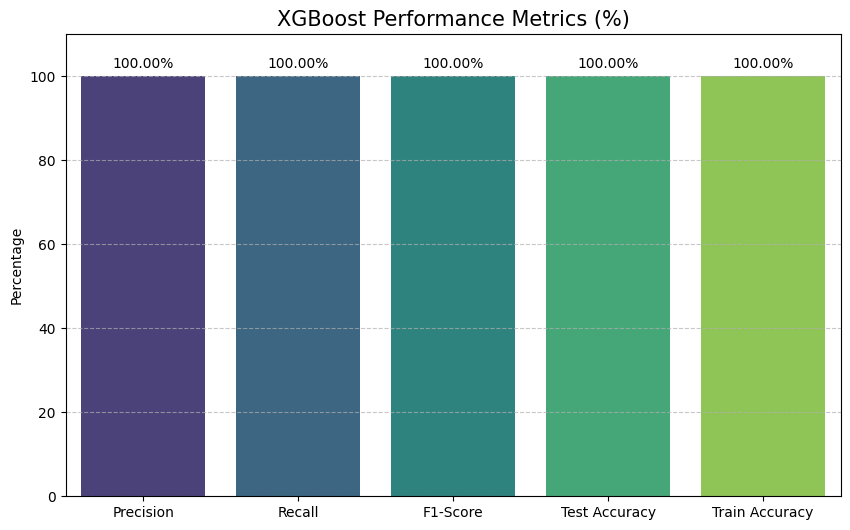

In [25]:
# Plot Grafik Accuracy
import seaborn as sns

# Data untuk plotting
metrics_names = ['Precision', 'Recall', 'F1-Score', 'Test Accuracy', 'Train Accuracy']
metrics_values = [precision_score_xg, recall_score_xg, f1_score_xg, test_accuracy_xg, train_accuracy_xg]

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=metrics_names, y=[v * 100 for v in metrics_values], palette='viridis')

# Menambahkan label angka di atas bar
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f') + '%',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points')

plt.ylim(0, 110)
plt.title('XGBoost Performance Metrics (%)', fontsize=15)
plt.ylabel('Percentage')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

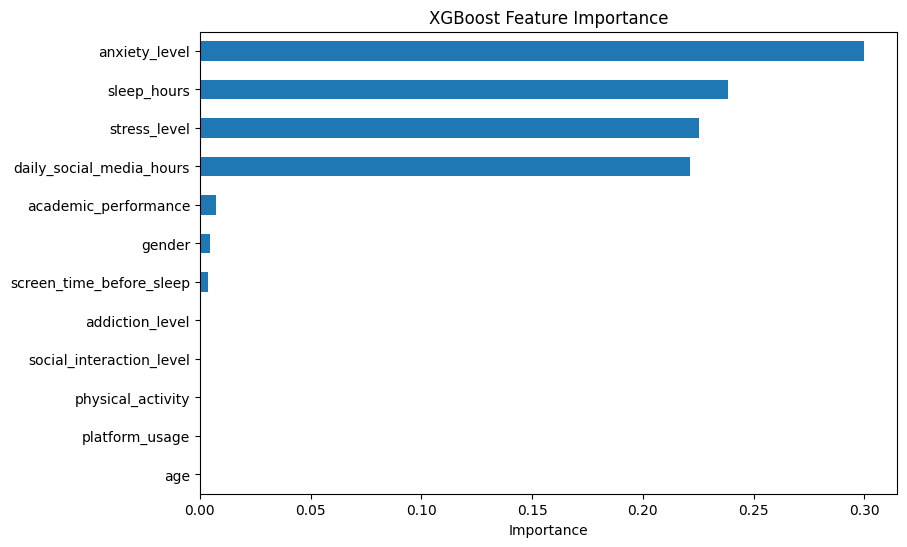

In [26]:
pd.Series(model_xg.feature_importances_, index=X_train.columns).sort_values().plot.barh(
    figsize=(9,6), title='XGBoost Feature Importance', xlabel='Importance'
)
plt.show()

In [27]:
param_grid = {
    'max_depth': [5, 8, 11],
    'learning_rate': [0.01, 0.05, 0.1,0.03],
    'n_estimators': [100, 200,300,500],
    # 'scale_pos_weight': [1, 3, 5]
}
param = {
    "max_depth": [9, 10, 11, 12, 13],
    "learning_rate": [0.05, 0.06, 0.07, 0.08, 0.09],
    "n_estimators": [80, 100, 120, 150]
}
search = GridSearchCV(
        XGBClassifier(random_state=42,n_jobs=1),
        param_grid=param_grid,
        scoring='f1_macro',
        cv=5,
        n_jobs=1
)

search.fit(X_train, y_train)
print(f"Best Score: {search.best_score_}")
print(f"Best Params: {search.best_params_}")

Best Score: 0.9630903073286052
Best Params: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 300}


# Random Forest Classifier

 Time := 0.36  seconds
Accuracy Score on Training Data:  0.9978609625668449
Accuracy Score on Testing Data:  0.9958333333333333
Recall Score on Testing Data:  1.0
Precision Score on Testing Data:  0.8571428571428571
F1 Score on Testing Data:  0.9230769230769231


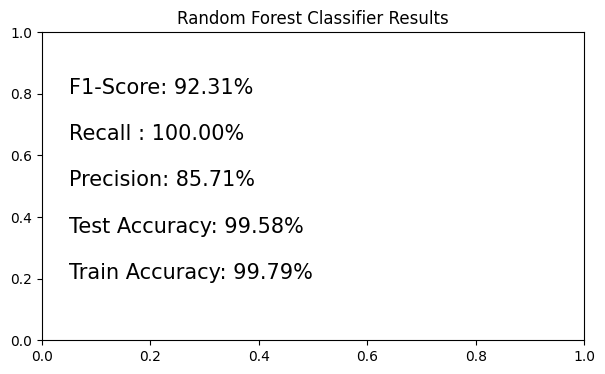

In [28]:
starttime=time.perf_counter()

model_rf = RandomForestClassifier(
    max_depth=3,
    n_estimators=90,
    n_jobs = -1,
    random_state=42,
    max_features='sqrt',
)

model_rf.fit(X_train_resampled, y_train_resampled)

# Training Model with Random Forest
train_prediction_rf = model_rf.predict(X_train_resampled)
test_prediction_rf = model_rf.predict(X_test)

# Accuracy Score
train_accuracy_rf = accuracy_score(y_train_resampled, train_prediction_rf)
test_accuracy_rf = accuracy_score(y_test, test_prediction_rf)

# Evaluation Score
recall_score_rf = recall_score(y_test, test_prediction_rf)
precision_score_rf = precision_score(y_test, test_prediction_rf)
f1_score_rf = f1_score(y_test, test_prediction_rf)
cm_rf = confusion_matrix(y_test, test_prediction_rf)

print(' Time :=',format(time.perf_counter()-starttime,'.2f'),' seconds')
print('Accuracy Score on Training Data: ', train_accuracy_rf)
print('Accuracy Score on Testing Data: ', test_accuracy_rf)
print('Recall Score on Testing Data: ', recall_score_rf)
print('Precision Score on Testing Data: ', precision_score_rf)
print('F1 Score on Testing Data: ', f1_score_rf)

# Plot Visualization
plt.figure(figsize=(7, 4))
plt.title('Random Forest Classifier Results')
plt.text(0.05, 0.65, f"Recall : {recall_score_rf * 100:.2f}%", fontsize=15, ha='left')
plt.text(0.05, 0.50, f"Precision: {precision_score_rf * 100:.2f}%", fontsize=15, ha='left')
plt.text(0.05, 0.80, f"F1-Score: {f1_score_rf * 100:.2f}%", fontsize=15, ha='left')
plt.text(0.05, 0.20, f"Train Accuracy: {train_accuracy_rf * 100:.2f}%", fontsize=15, ha='left')
plt.text(0.05, 0.35, f"Test Accuracy: {test_accuracy_rf * 100:.2f}%", fontsize=15, ha='left')
plt.show()

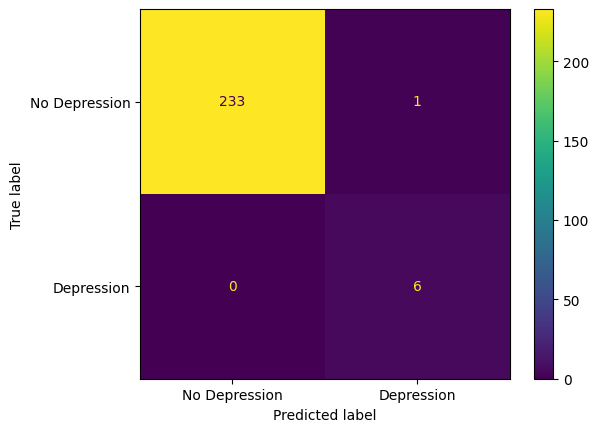

In [29]:
# Confusion Matrix Display
ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=['No Depression', 'Depression']
).plot()

plt.show()

/tmp/ipykernel_3330/4126068008.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=metrics_names, y=[v * 100 for v in metrics_values], palette='viridis')


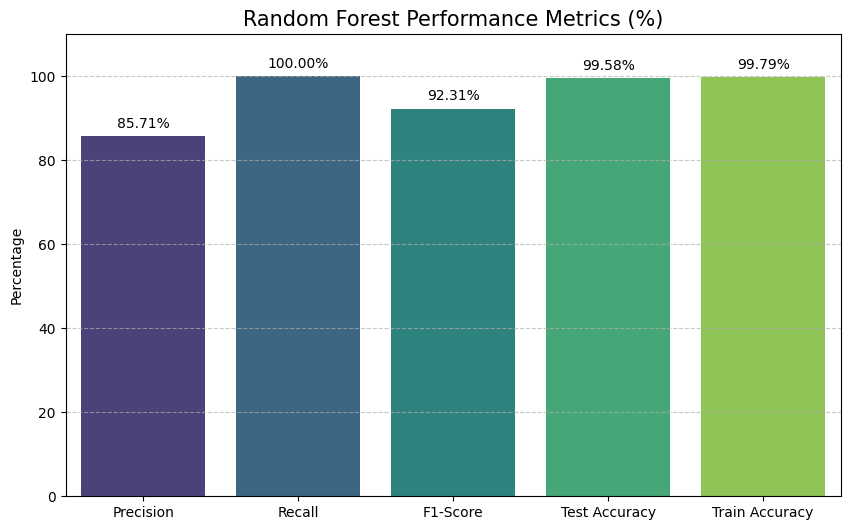

In [30]:
# Plot Grafik Accuracy
import seaborn as sns

# Data untuk plotting
metrics_names = ['Precision', 'Recall', 'F1-Score', 'Test Accuracy', 'Train Accuracy']
metrics_values = [precision_score_rf, recall_score_rf, f1_score_rf, test_accuracy_rf, train_accuracy_rf]

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=metrics_names, y=[v * 100 for v in metrics_values], palette='viridis')

# Menambahkan label angka di atas bar
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f') + '%',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points')

plt.ylim(0, 110)
plt.title('Random Forest Performance Metrics (%)', fontsize=15)
plt.ylabel('Percentage')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

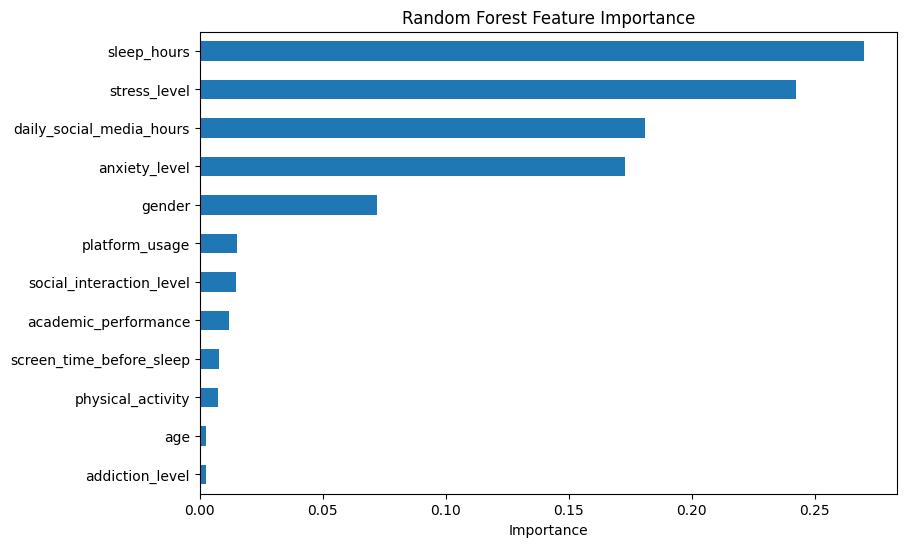

In [31]:
pd.Series(model_rf.feature_importances_, index=X_train.columns).sort_values().plot.barh(
    figsize=(9,6), title='Random Forest Feature Importance', xlabel='Importance'
)
plt.show()

# Inference

In [32]:
# Print All Accuracy Models
print('Decision Tree Accuracy: ',test_accuracy_dt)
print('XGBoost Accuracy: ',test_accuracy_xg)
print('Random Forest Accuracy: ',test_accuracy_rf)

Decision Tree Accuracy:  0.9916666666666667
XGBoost Accuracy:  1.0
Random Forest Accuracy:  0.9958333333333333


In [33]:
import pandas as pd

# Skenario 1: Potensi Depresi (Tidur kurang, stress tinggi, sosmed lama)
data_potensi_depresi = {
    'sleep_hours': [2],
    'stress_level': [9],
    'daily_social_media_hours': [8],
    'anxiety_level': [8],
    'gender': [1],
    'platform_usage': [2],
    'social_interaction_level': [2],
    'academic_performance': [2],
    'screen_time_before_sleep': [3],
    'physical_activity': [1],
    'age': [17],
    'addiction_level': [7]
}

# Skenario 2: Potensi Sehat (Tidur cukup, stress rendah, sosmed bijak)
data_potensi_sehat = {
    'sleep_hours': [8],
    'stress_level': [3],
    'daily_social_media_hours': [2],
    'anxiety_level': [2],
    'gender': [0],
    'platform_usage': [1],
    'social_interaction_level': [4],
    'academic_performance': [4],
    'screen_time_before_sleep': [1],
    'physical_activity': [4],
    'age': [18],
    'addiction_level': [2]
}

# Ubah ke DataFrame
df_test_1 = pd.DataFrame(data_potensi_depresi)
df_test_2 = pd.DataFrame(data_potensi_sehat)

# Pastikan urutan kolom sama persis dengan X_train
df_test_1 = df_test_1[X_train.columns]
df_test_2 = df_test_2[X_train.columns]

In [34]:
def run_inference(df_input, nama_tes):
    print(f"--- Hasil untuk {nama_tes} ---")

    # Prediksi
    res_dt = model_dt.predict(df_input)[0]
    res_xg = model_xg.predict(df_input)[0]
    res_rf = model_rf.predict(df_input)[0]

    # Mapping (Sesuaikan 0/1 dengan dataset)
    mapping = {0: "No Depression", 1: "Depression"}

    print(f"Decision Tree : {mapping[res_dt]}")
    print(f"XGBoost       : {mapping[res_xg]}")
    print(f"Random Forest : {mapping[res_rf]}")

    # Lihat probabilitas di Random Forest
    prob = model_rf.predict_proba(df_input)[0][1]
    print(f"Confidence (RF): {prob*100:.2f}%")
    print("\n")

# Eksekusi
run_inference(df_test_1, "User A (High Risk)")
run_inference(df_test_2, "User B (Low Risk)")

--- Hasil untuk User A (High Risk) ---
Decision Tree : Depression
XGBoost       : Depression
Random Forest : Depression
Confidence (RF): 58.66%


--- Hasil untuk User B (Low Risk) ---
Decision Tree : No Depression
XGBoost       : No Depression
Random Forest : No Depression
Confidence (RF): 0.39%




# Saved Model

In [35]:
!pip freeze > requirements.txt

In [36]:
import pickle

# Simpan Model
with open('model_rf.pkl', 'wb') as f:
    pickle.dump(model_rf, f)

# Simpan list kolom untuk memastikan urutan fitur tetap sama
with open('features.pkl', 'wb') as f:
    pickle.dump(X_train.columns.tolist(), f)